# Image Classification Pipeline
This notebook demonstrates an image classification workflow using cell-level features, following the logic from `cell_level_pipeline.py`. Steps include data loading, preprocessing, feature extraction, model training, evaluation, and prediction visualization.

In [2]:
# Section 1: Import Required Libraries
import os
import numpy as np
import pandas as pd
from skimage.feature import hog
from skimage import io, color
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, precision_recall_fscore_support, accuracy_score
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import time

## Section 2: Load and Preprocess Image Data
Load the annotation CSV and prepare the image dataset. Images are split into 8x8 cells, and features are extracted for each cell.

In [7]:
# Configuration
image_dir = r"C:\\Users\\pravi\\PG IITB\\cricket_object_detection\\data\\train_modified\\"
annotation_csv = r"C:\\Users\\pravi\\PG IITB\\cricket_object_detection\\outputs\\annotations_cells_modified.csv"
cell_height, cell_width = 75, 100  # For 800x600 images, 8x8 grid

# Load annotations
df = pd.read_csv(annotation_csv, encoding='latin1')

#group by image_name and get images having count > 64


In [8]:
# Feature extraction function
def extract_cell_features(cell_img):
    gray = color.rgb2gray(cell_img)
    hog_feat = hog(gray, pixels_per_cell=(8,8), cells_per_block=(1,1), feature_vector=True)
    mean = gray.mean()
    std = gray.std()
    return np.concatenate([hog_feat, [mean, std]])

# Prepare features and labels
feature_rows = []
img_files = df['image_name'].unique()
np.random.seed(42)
#img_files_sample = np.random.choice(img_files, size=min(150, len(img_files)), replace=False)

print("Total images to process:", len(img_files))

for img_name in img_files:
    img_path = os.path.join(image_dir, img_name)
    if not os.path.exists(img_path):
        continue
    img = io.imread(img_path)
    if img.shape[0] != 600 or img.shape[1] != 800:
        continue
    cell_labels = df[df['image_name'] == img_name].sort_values(['cell_row', 'cell_column'])[['cell_row', 'cell_column', 'label']].values
    idx = 0
    for r in range(8):
        for c in range(8):
            y1, y2 = r*cell_height, (r+1)*cell_height
            x1, x2 = c*cell_width, (c+1)*cell_width
            cell_img = img[y1:y2, x1:x2]
            features = extract_cell_features(cell_img)
            cell_row, cell_col, label = cell_labels[idx]
            row = {
                'image_name': img_name,
                'cell_row': cell_row,
                'cell_column': cell_col,
                'label': label
            }
            for i, val in enumerate(features):
                row[f'feat_{i}'] = val
            feature_rows.append(row)
            idx += 1
features_df = pd.DataFrame(feature_rows)
print("Extracted features for", len(features_df), "cells")

Total images to process: 202
Extracted features for 12864 cells


## Section 3: Define Model Architecture
Train Random Forest and KNN classifiers using the extracted cell features.

In [9]:
# Prepare X, y for training
X = features_df[[col for col in features_df.columns if col.startswith('feat_')]].values
y = features_df['label'].values

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train, y_train)

# KNN
knn_clf = KNeighborsClassifier(n_neighbors=5)
knn_clf.fit(X_train, y_train)

KNeighborsClassifier()

## Section 4: Train the Model
Training was performed above. Now, evaluate the trained models.

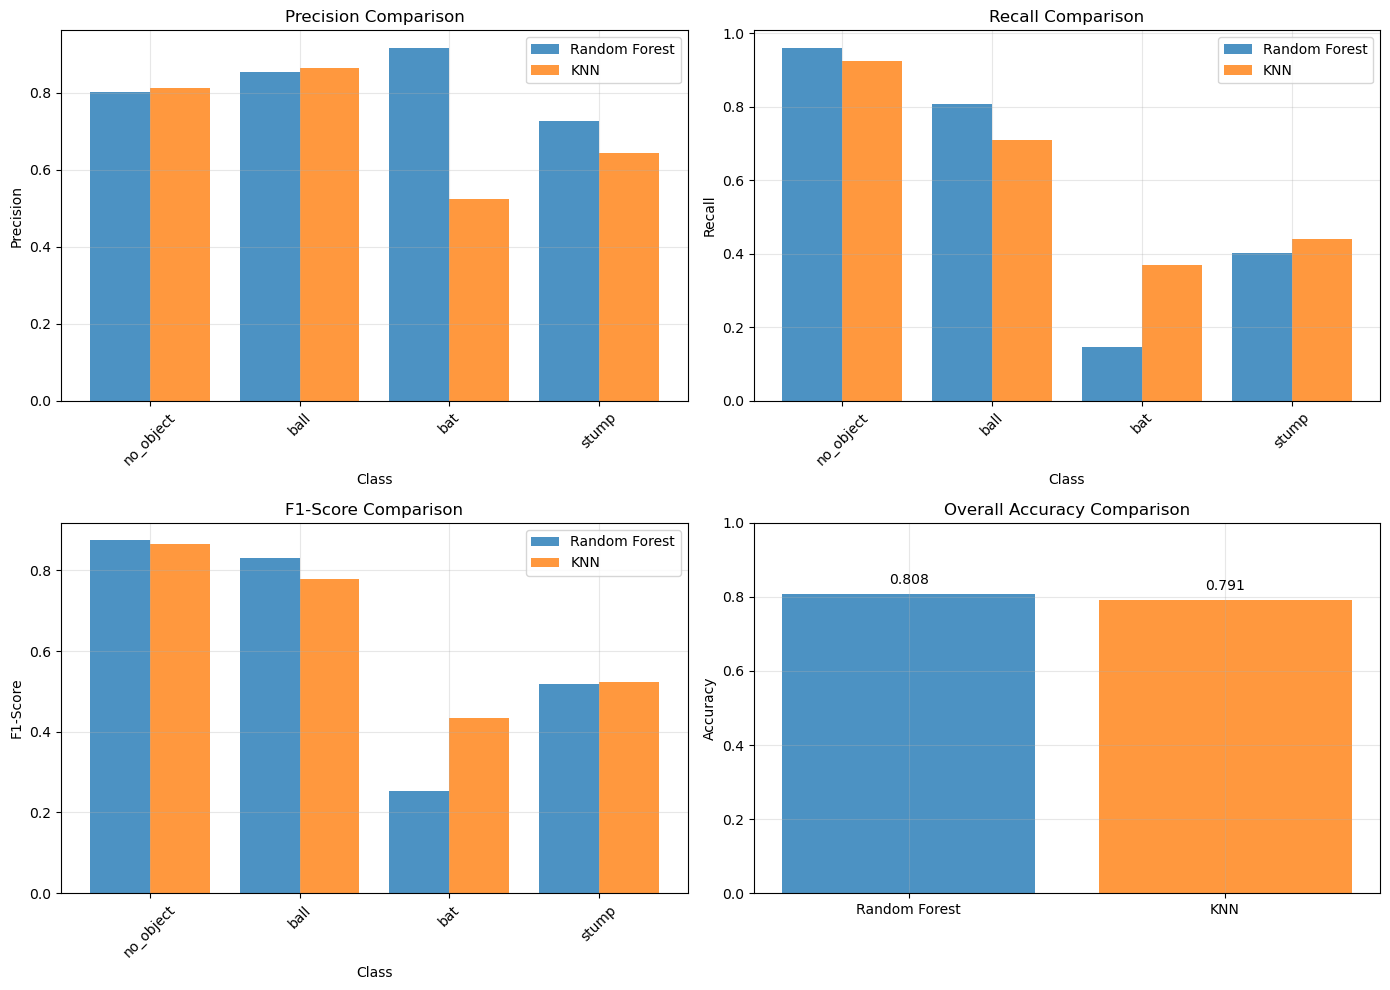


=== Model Comparison Summary ===

    Class  RF Precision  KNN Precision  RF Recall  KNN Recall  RF F1-Score  KNN F1-Score
no_object      0.802209       0.813658   0.960337    0.923678     0.874179      0.865184
     ball      0.854637       0.864162   0.808057    0.708531     0.830694      0.778646
      bat      0.916667       0.525316   0.147321    0.370536     0.253846      0.434555
    stump      0.726027       0.644444   0.403042    0.441065     0.518337      0.523702

Random Forest Accuracy: 0.8076
KNN Accuracy: 0.7909


In [10]:
# Evaluate Model Performance
labels = [0, 1, 2, 3]
class_names = ['no_object', 'ball', 'bat', 'stump']
rf_pred = rf_clf.predict(X_test)
knn_pred = knn_clf.predict(X_test)
# print("Random Forest Classification Report:")
# print(classification_report(y_test, rf_pred, target_names=class_names))
# print("KNN Classification Report:")
# print(classification_report(y_test, knn_pred, target_names=class_names))

#instead of printing the report, do the comparison in graphical way

# Compute metrics for both models
rf_metrics = precision_recall_fscore_support(y_test, rf_pred, labels=labels, average=None)
knn_metrics = precision_recall_fscore_support(y_test, knn_pred, labels=labels, average=None)

rf_accuracy = accuracy_score(y_test, rf_pred)
knn_accuracy = accuracy_score(y_test, knn_pred)

# Create comparison dataframe
comparison_data = {
    'Class': class_names,
    'RF Precision': rf_metrics[0],
    'KNN Precision': knn_metrics[0],
    'RF Recall': rf_metrics[1],
    'KNN Recall': knn_metrics[1],
    'RF F1-Score': rf_metrics[2],
    'KNN F1-Score': knn_metrics[2]
}
comparison_df = pd.DataFrame(comparison_data)

# Plot comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Precision comparison
axes[0, 0].bar(np.arange(len(class_names)) - 0.2, rf_metrics[0], 0.4, label='Random Forest', alpha=0.8)
axes[0, 0].bar(np.arange(len(class_names)) + 0.2, knn_metrics[0], 0.4, label='KNN', alpha=0.8)
axes[0, 0].set_xlabel('Class')
axes[0, 0].set_ylabel('Precision')
axes[0, 0].set_title('Precision Comparison')
axes[0, 0].set_xticks(np.arange(len(class_names)))
axes[0, 0].set_xticklabels(class_names, rotation=45)
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Recall comparison
axes[0, 1].bar(np.arange(len(class_names)) - 0.2, rf_metrics[1], 0.4, label='Random Forest', alpha=0.8)
axes[0, 1].bar(np.arange(len(class_names)) + 0.2, knn_metrics[1], 0.4, label='KNN', alpha=0.8)
axes[0, 1].set_xlabel('Class')
axes[0, 1].set_ylabel('Recall')
axes[0, 1].set_title('Recall Comparison')
axes[0, 1].set_xticks(np.arange(len(class_names)))
axes[0, 1].set_xticklabels(class_names, rotation=45)
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# F1-Score comparison
axes[1, 0].bar(np.arange(len(class_names)) - 0.2, rf_metrics[2], 0.4, label='Random Forest', alpha=0.8)
axes[1, 0].bar(np.arange(len(class_names)) + 0.2, knn_metrics[2], 0.4, label='KNN', alpha=0.8)
axes[1, 0].set_xlabel('Class')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('F1-Score Comparison')
axes[1, 0].set_xticks(np.arange(len(class_names)))
axes[1, 0].set_xticklabels(class_names, rotation=45)
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Overall Accuracy comparison
axes[1, 1].bar(['Random Forest', 'KNN'], [rf_accuracy, knn_accuracy], color=['#1f77b4', '#ff7f0e'], alpha=0.8)
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Overall Accuracy Comparison')
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(True, alpha=0.3)
for i, (model, acc) in enumerate(zip(['Random Forest', 'KNN'], [rf_accuracy, knn_accuracy])):
    axes[1, 1].text(i, acc + 0.02, f'{acc:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Print comparison summary
print("\n=== Model Comparison Summary ===\n")
print(comparison_df.to_string(index=False))
print(f"\n{'='*60}")
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"KNN Accuracy: {knn_accuracy:.4f}")
print(f"{'='*60}")

#

## Section 5: Make Predictions on New Images
Use the trained Random Forest model to predict cell labels for new images and save results to CSV.

In [13]:
# Save Model Predictions to CSV
from sklearn.model_selection import train_test_split

def save_final_predictions(features_df, rf_clf, image_dir, cell_height, cell_width):
    import csv
    # Get unique image names
    unique_images = features_df['image_name'].unique()
    # Split images into train and test sets (80/20)
    train_imgs, test_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)
    print(f"Number of train images: {len(train_imgs)}")
    print(f"Number of test images: {len(test_imgs)}")
    print(f"Overlap: {len(set(train_imgs).intersection(set(test_imgs)))}")
    def predict_and_save(img_list, dataset_type, model, out_writer):
        for img_name in img_list:
            img_path = os.path.join(image_dir, img_name)
            if not os.path.exists(img_path):
                continue
            img = io.imread(img_path)
            if img.shape[0] != 600 or img.shape[1] != 800:
                continue
            preds = []
            for r in range(8):
                for c in range(8):
                    y1, y2 = r*cell_height, (r+1)*cell_height
                    x1, x2 = c*cell_width, (c+1)*cell_width
                    cell_img = img[y1:y2, x1:x2]
                    features = extract_cell_features(cell_img)
                    pred = model.predict([features])[0]
                    preds.append(pred)
            row = [img_name, dataset_type] + preds
            out_writer.writerow(row)
    output_csv_path = r"C:\Users\pravi\PG IITB\cricket_object_detection\outputs\final_predictions_test.csv"
    with open(output_csv_path, 'w', newline='') as f:
        writer = csv.writer(f)
        header = ['ImageFileName', 'TrainOrTest'] + [f'c{str(i+1).zfill(2)}' for i in range(64)]
        writer.writerow(header)
        predict_and_save(train_imgs, 'Train', rf_clf, writer)
        predict_and_save(test_imgs, 'Test', rf_clf, writer)
    print(f"Final predictions saved to {output_csv_path}")

save_final_predictions(features_df, rf_clf, image_dir, cell_height, cell_width)


Number of train images: 160
Number of test images: 41
Overlap: 0
Final predictions saved to C:\Users\pravi\PG IITB\cricket_object_detection\outputs\final_predictions_test.csv
Final predictions saved to C:\Users\pravi\PG IITB\cricket_object_detection\outputs\final_predictions_test.csv
